In [2]:
"""SD3-M Prompt-based Image Editing

Based on: "Exploring Multimodal Diffusion Transformers for Enhanced Prompt-based Image Editing"
"""

import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusion3Pipeline

import sys
sys.path.append("..")
from utils import (
    register_qkv_control,
    create_qkv_controller,
    p2p_callback,
    TOP5_BLOCKS,
)

pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3-medium-diffusers", torch_dtype=torch.float16
).to("cuda")


/opt/conda/envs/exp-mmdit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 9/9 [00:00<00:00, 11.17it/s]


Registered 24 attention processors (SDPA: True).


100%|██████████| 28/28 [00:12<00:00,  2.23it/s]


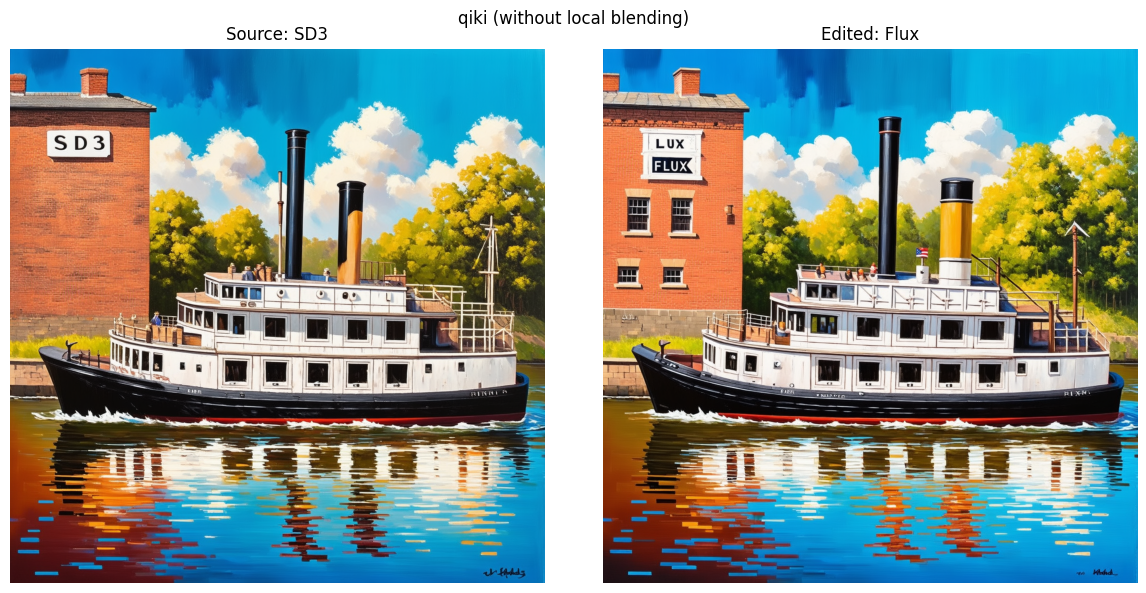

In [3]:
# Basic Replace (qiki) - without local blending

prompts = ["beautiful oil painting of a steamboat in a river in the afternoon. On the side of the river is a large brick building with a sign on top that says 'SD3'",
           "beautiful oil painting of a steamboat in a river in the afternoon. On the side of the river is a large brick building with a sign on top that says 'FLUX'"]

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    t5_max_seq_len=256,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=256,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: SD3")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: Flux")
ax[1].axis("off")
plt.suptitle("qiki (without local blending)")
plt.tight_layout()

Registered 24 attention processors (SDPA: True).


100%|██████████| 28/28 [00:14<00:00,  1.93it/s]


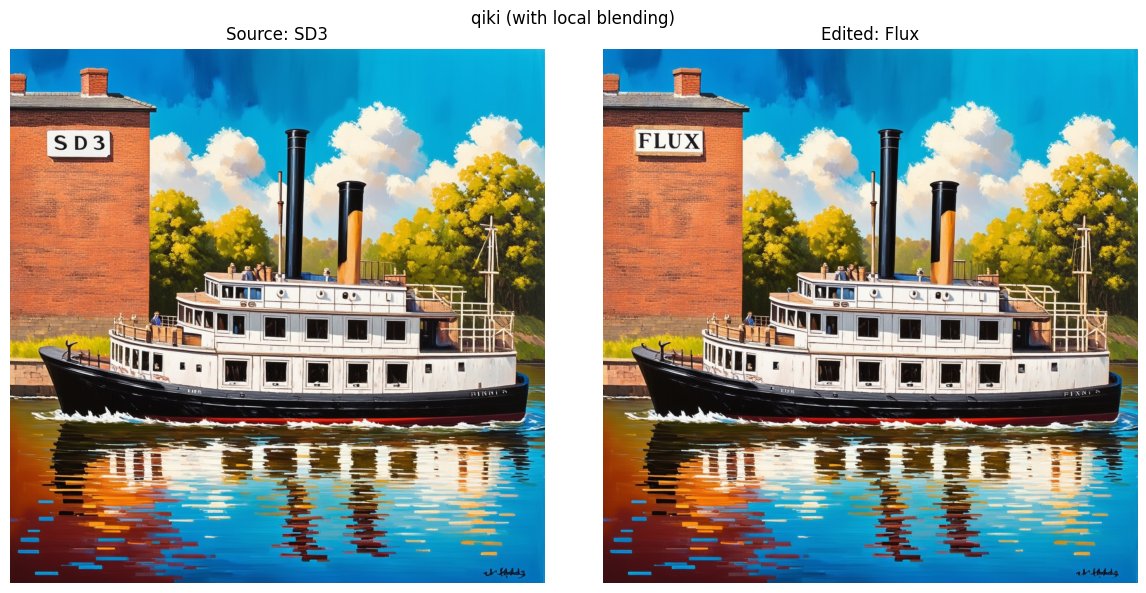

In [4]:
# Replace (qiki) - with local blending

prompts = ["beautiful oil painting of a steamboat in a river in the afternoon. On the side of the river is a large brick building with a sign on top that says 'SD3'",
           "beautiful oil painting of a steamboat in a river in the afternoon. On the side of the river is a large brick building with a sign on top that says 'FLUX'"]

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    local_blend_words= [["'SD3'"], ["'FLUX'"]],
    aggregate_blocks=TOP5_BLOCKS["sd3-m"],
    local_blend_threshold=0.85,
    t5_max_seq_len=256,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=256,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: SD3")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: Flux")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Registered 24 attention processors (SDPA: True).


100%|██████████| 28/28 [00:14<00:00,  1.91it/s]


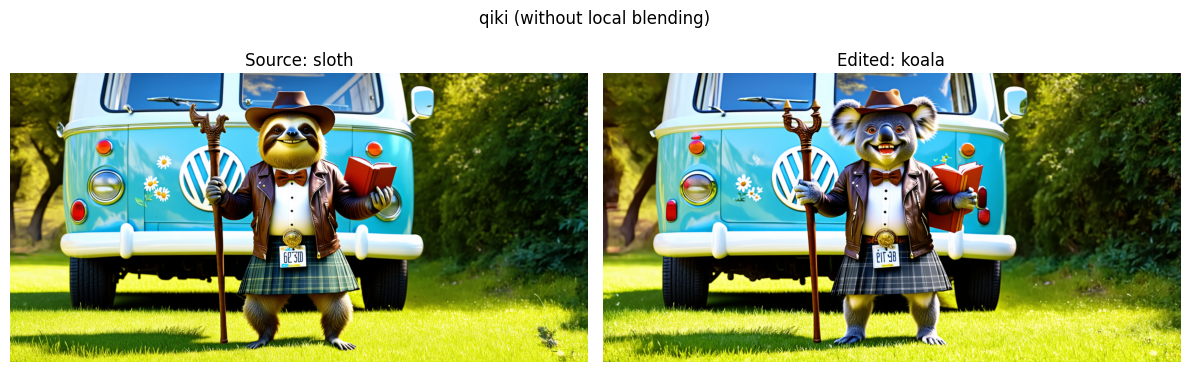

In [5]:
# Basic Replace (qiki) - without local blending, Non-square images are also supported!

prompts = ["A smiling sloth is wearing a leather jacket, a cowboy hat, a kilt and a bowtie. The sloth is holding a quarterstaff and a big book. The sloth is standing on grass a few feet in front of a shiny VW van with flowers painted on it. wide-angle lens from below.",
           "A smiling koala is wearing a leather jacket, a cowboy hat, a kilt and a bowtie. The koala is holding a quarterstaff and a big book. The koala is standing on grass a few feet in front of a shiny VW van with flowers painted on it. wide-angle lens from below."]

height, width = 768, 1536
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

controller = create_qkv_controller(
    pipeline_type="sd3",
    prompts=prompts,
    num_inference_steps=28,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    t5_max_seq_len=256,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=28,
    guidance_scale=7.0,
    height=height,
    width=width,
    max_sequence_length=256,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(images[0])
ax[0].set_title("Source: sloth")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: koala")
ax[1].axis("off")
plt.suptitle("qiki (without local blending)")
plt.tight_layout()

Registered 24 attention processors (SDPA: True).


100%|██████████| 28/28 [00:13<00:00,  2.13it/s]


Registered 24 attention processors (SDPA: False).


100%|██████████| 28/28 [00:47<00:00,  1.70s/it]


Registered 24 attention processors (SDPA: False).


100%|██████████| 28/28 [00:46<00:00,  1.67s/it]


Registered 24 attention processors (SDPA: False).


100%|██████████| 28/28 [00:46<00:00,  1.67s/it]


Registered 24 attention processors (SDPA: False).


100%|██████████| 28/28 [00:46<00:00,  1.67s/it]


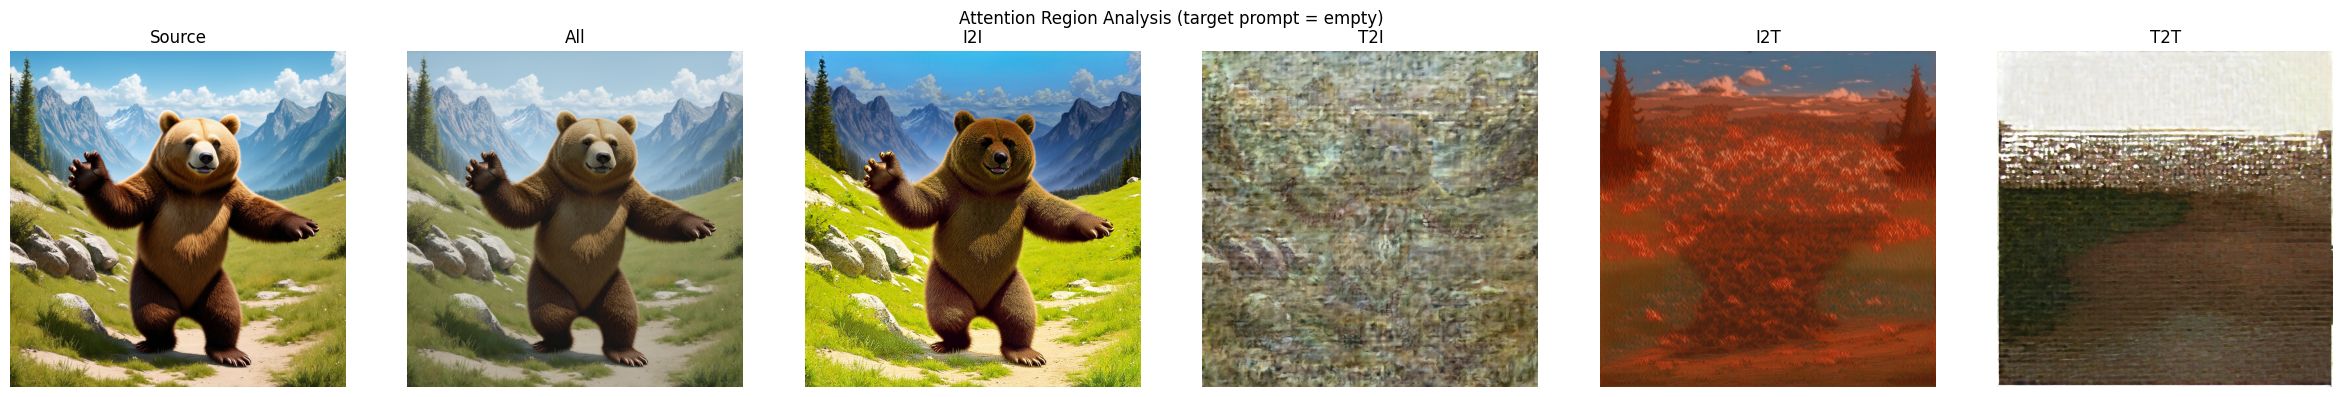

In [6]:
# Impact of each attention region (Fig. A2)
# Shows how different attention regions affect generation when target prompt is empty

prompts = [
    "a photo-realistic bear dancing in the mountains",
    "",  # Empty target prompt to isolate attention region effects
]
height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2, pipe.tokenizer_3]

# Test different methods with full replacement (replace_steps=1.0)
methods = ["qk", "I2I", "T2I", "I2T", "T2T"]
results = {}
source_img = None
for method in methods:
    controller = create_qkv_controller(
        pipeline_type="sd3",
        prompts=prompts,
        num_inference_steps=28,
        tokenizer=tokenizers,
        device=pipe.device,
        dtype=pipe.dtype,
        method=method,
        replace_steps=1.0,
        t5_max_seq_len=256,
        height=height,
        width=width,
    )
    register_qkv_control(pipe, controller)
    imgs = pipe(
        prompt=prompts,
        num_inference_steps=28,
        guidance_scale=7.0,
        height=height,
        width=width,
        max_sequence_length=256,
        generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
        callback_on_step_end=p2p_callback,
        callback_on_step_end_tensor_inputs=["latents"],
    ).images
    if source_img is None:
        source_img = imgs[0]
    results[method] = imgs[1]
    controller.reset()

# Plot: Source | All | I2I | T2I | I2T | T2T
fig, ax = plt.subplots(1, 6, figsize=(24, 4))
ax[0].imshow(source_img)
ax[0].set_title("Source")
ax[0].axis("off")
for i, method in enumerate(methods):
    ax[i+1].imshow(results[method])
    ax[i+1].set_title("All" if method == "qk" else method)
    ax[i+1].axis("off")
plt.suptitle("Attention Region Analysis (target prompt = empty)")
plt.tight_layout()

In [7]:
del pipe
torch.cuda.empty_cache()
print("Done!")

Done!
